## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Rushil Nanga]

**Date:** [9/30/2026]

1.1 Regression is used to predict numerical values while classification is used to predict categories or classes

1.2 A confusion table compares the actual classes to the classes predicted by a model. It helps us look at how many predictions were correct and which classes the model confused with one another

1.3 The Sum of Squared Errors is used to measure the total squared difference between the actual values and the values predicted by a model. A lower SSE means that the predictions are closer to the actual values and vice versa

1.4 Overfitting happens when a model fits the training data too closely and does not perform well when involved with new data. Underfitting happens when a model is too simple and does not capture enough of the patterns that exist in the data

1.5 Splitting the data is useful to train the model on one set of observations and evaluate it on observations that the model hasn't seen before. Testing different values of k on the test set helps choose a value that performs nicely on new data instead of only fitting the training data

1.6 A class label provides one final prediction making it easy to use, but it does not show how confident the model is. A probability distribution gives the probability of each possible class which provides more information about uncertainty, but it is more complicated to interpret

In [5]:
!git clone https://github.com/rushilnanga/A03-knn.git
%cd /content/A03-knn
!ls

Cloning into 'A03-knn'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 15 (delta 4), reused 0 (delta 0), pack-reused 9 (from 2)
Receiving objects: 100% (15/15), 11.12 KiB | 1.59 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/A03-knn
A03-knn  data  notebook.ipynb  README.md


In [6]:
import pandas as pd

df = pd.read_csv("data/land_mines.csv")

print(df.head())
print()
print(df.shape)
print()
print(df.info())
print()
print(df.describe())
print()
print(df["mine_type"].value_counts())

# The target variable in the dataset was the mine type and its features were voltage, height, and soil. I looked at the size of the dataset, summary statistics, data types, and the number of observations in each mine type before building the model.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

(338, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455 

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    accuracies.append(accuracy)
    print("k =", k, "Accuracy =", round(accuracy, 3))

best_k = accuracies.index(max(accuracies)) + 1

print()
print("Best k:", best_k)
print("Best accuracy:", round(max(accuracies), 3))

# I tested values of k from 1 to 20 and compared their accuracy on the testing data and ended up selecting the value of k that produced the highest accuracy

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

confusion = confusion_matrix(y_test, predictions)

confusion_table = pd.DataFrame(
    confusion,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)

print(confusion_table)
print()
print("Accuracy:", round(accuracy_score(y_test, predictions), 3))

2.5 I wouldn't use this model as the only method for identifying a land mine. Even if the model does make many correct predictions, some of the mine types can still be confused with the other types. As making an incorrect prediction could be dangerous, the model should be used as an additional tool to help with identification instead of something that's used as the final decision.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [82ab347]
- **AI tool and model used:** [ChatGPT]

### *Prompts used

1. Review my Phase 1 k nearest neighbor analysis of the land_mines.csv data. Suggest specific improvements to the EDA, data preparation, model construction, model selection, evaluation, visualizations, and interpretation.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Check the dataset for missing values and duplicate rows before modeling.

2. Add visualizations of the predictor variables and mine-type distribution to improve the exploratory data analysis.

3. Use a stratified 50/50 train-test split so that each mine type is represented proportionally in both sets.

4. Standardize voltage, height, and soil before fitting k-NN because k-NN relies on distances between observations.

5. Evaluate a range of k values and graph accuracy against k instead of only printing the results.

6. Use cross-validation on the training data to select k rather than choosing k based directly on the final test set.

7. Add class-level performance measures in addition to overall accuracy and the confusion matrix.

8. Display the confusion matrix as a heatmap to make patterns in incorrect classifications easier to identify.

9. Create additional interaction and polynomial features from voltage, height, and soil to try to improve predictive accuracy.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
1	Accept	Checking missing values and duplicates verifies the data are ready for modeling
2	Accept	Visualizations make the feature distributions and class balance easier to understand
3	Accept	Stratification helps preserve the distribution of the five mine types in both halves of the data
4	Accept	k-NN uses distances so standardization will help prevent feature scale from affecting distance calculations
5	Accept	The graph makes it easier to see how model performance changes with k rather than relying only on printed numbers
6	Accept	Cross-validation selects k using only the training data leaving the test data for final evaluation
7	Accept	Class-level metrics reveal performance differences that overall accuracy can hide
8	Accept	A visual confusion matrix makes misclassifications easier to identify.
9	Reject	Unneccesarily adds complexity without a clear justification

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Shape: (338, 4)

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Duplicate rows: 0

Summary statistics:
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


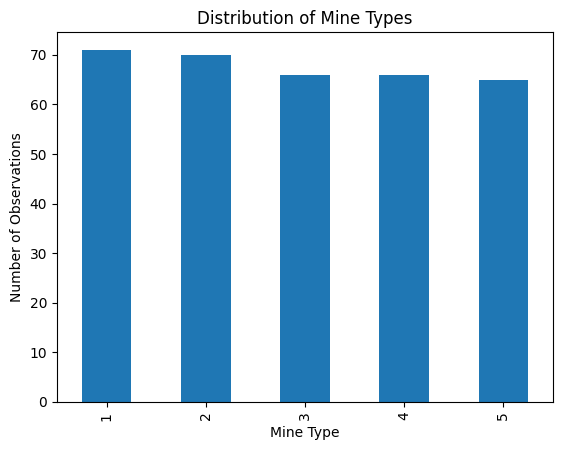

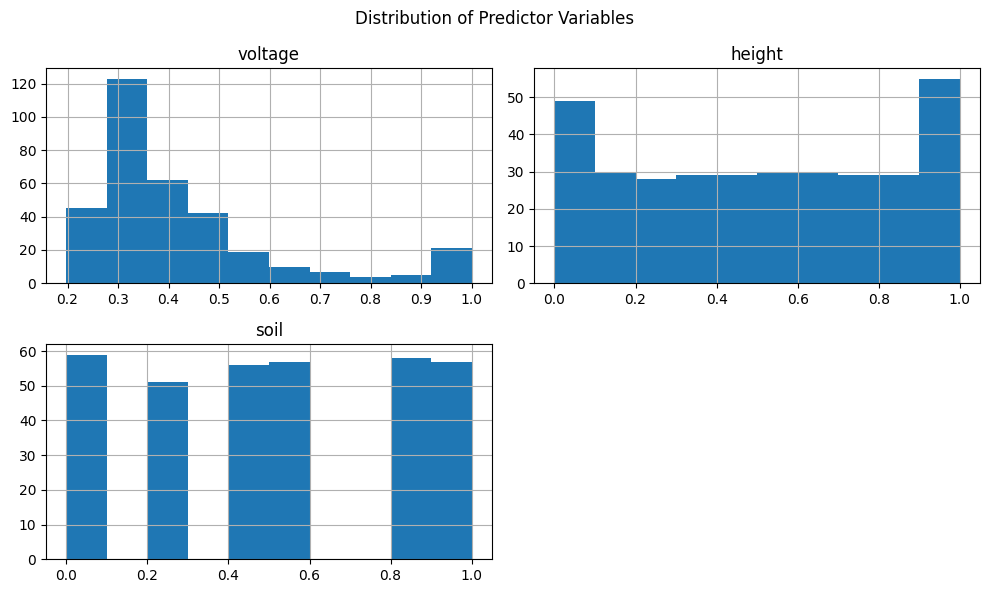

In [9]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/land_mines.csv")

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Number of Observations")
plt.title("Distribution of Mine Types")
plt.show()

df[["voltage", "height", "soil"]].hist(figsize=(10, 6))

plt.suptitle("Distribution of Predictor Variables")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

Training size: 169
Testing size: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Testing class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


k = 1 CV Accuracy = 0.414
k = 2 CV Accuracy = 0.455
k = 3 CV Accuracy = 0.396
k = 4 CV Accuracy = 0.426
k = 5 CV Accuracy = 0.455
k = 6 CV Accuracy = 0.48
k = 7 CV Accuracy = 0.468
k = 8 CV Accuracy = 0.45
k = 9 CV Accuracy = 0.456
k = 10 CV Accuracy = 0.45
k = 11 CV Accuracy = 0.426
k = 12 CV Accuracy = 0.426
k = 13 CV Accuracy = 0.42
k = 14 CV Accuracy = 0.397
k = 15 CV Accuracy = 0.39
k = 16 CV Accuracy = 0.367
k = 17 CV Accuracy = 0.361
k = 18 CV Accuracy = 0.384
k = 19 CV Accuracy = 0.402
k = 20 CV Accuracy = 0.366

Best k: 6
Best CV accuracy: 0.48


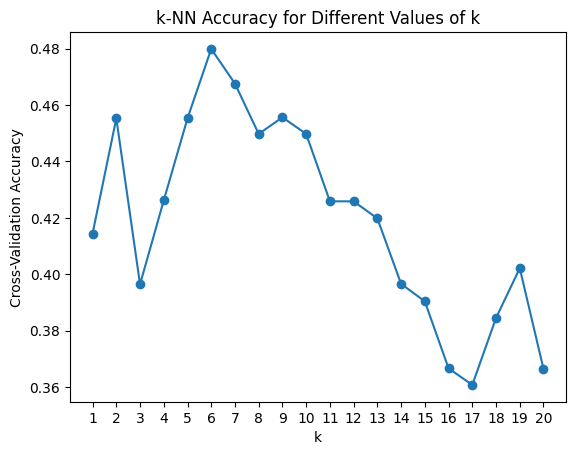

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())
    print("k =", k, "CV Accuracy =", round(scores.mean(), 3))

best_k = list(k_values)[cv_scores.index(max(cv_scores))]

print()
print("Best k:", best_k)
print("Best CV accuracy:", round(max(cv_scores), 3))

plt.plot(k_values, cv_scores, marker="o")

plt.xlabel("k")
plt.ylabel("Cross-Validation Accuracy")
plt.title("k-NN Accuracy for Different Values of k")
plt.xticks(range(1, 21))
plt.show()


          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           23            0            7            5            1
Actual 2            0           34            0            1            0
Actual 3            9            3            5            6           10
Actual 4           15            5            7            3            3
Actual 5            9            2           10            6            5

Test Accuracy: 0.414

Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.64      0.50        36
           2       0.77      0.97      0.86        35
           3       0.17      0.15      0.16        33
           4       0.14      0.09      0.11        33
           5       0.26      0.16      0.20        32

    accuracy                           0.41       169
   macro avg       0.35      0.40      0.37       169
weighted avg       0.36      0.41      0.38       169



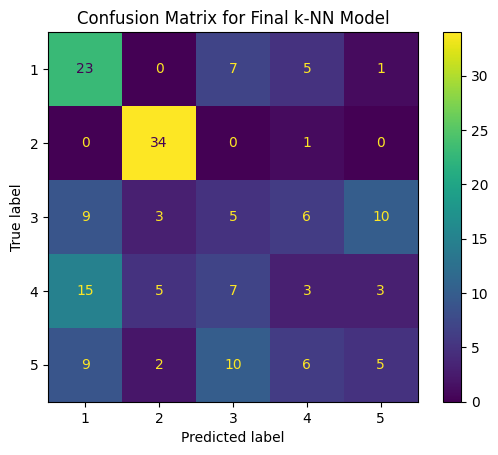

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)

predictions = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

confusion = confusion_matrix(y_test, predictions)

confusion_table = pd.DataFrame(
    confusion,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)

print(confusion_table)
print()
print("Test Accuracy:", round(accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[1, 2, 3, 4, 5]
).plot()

plt.title("Confusion Matrix for Final k-NN Model")
plt.show()

2.5 I would not recommend using this model as the only method for identifying a land mine. Overall accuracy alone does not show how reliably the model identifies each mine type. The confusion matrix and class-level precision and recall show which mine types are more likely to be confused with others. In a safety-sensitive situation, these errors could have serious consequences. I would therefore use the model only as supporting information alongside other identification methods and expert judgment.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements I made in Phase 2 was focused on making the analysis more reliable and giving a better picture of the model's performance. I added checks for missing values and duplicates and included visualizations to better understand the data. I also changed the 50/50 train test split to be layered so that each mine type was represented similarly in both sets. Since k-NN is based on distance, I standardized the predictor variables so that differences in their scales would not have an unfair effect on the model. I also improved how k was selected by using cross validation on the training data instead of repeatedly using the test data. Finally, I added precision, recall, F1-score, and a visual confusion matrix to better evaluate performance for each mine type.

The AI suggestion that I rejected was the one that created polynomial or interaction features from the existing predictors. I thought that this would add unnecessary complexity without a clear reason that these constructed features would improve the model.

I verified the changes by rerunning the notebook, checking the class distributions after the split, comparing the cross-validation results for different values of k, and evaluating the final model on the test set. I also compared the confusion matrix with the classification report to make sure the results were consistent. A remaining concern is that the dataset only contains 338 observations and the model still makes classification errors. Because identifying land mines is safety sensitive, I wouldn't rely on this model as the only method of identification.